In [28]:
# --- Cell 1: ライブラリのインポートと基本設定 ---
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Optional, Tuple, Sequence

# 画像読み込み用ライブラリの準備
try:
    import imageio.v3 as iio
except ImportError:
    iio = None
    print("Warning: imageio not found. Trying tifffile...")

try:
    import tifffile
except ImportError:
    tifffile = None
    print("Warning: tifffile not found.")

if iio is None and tifffile is None:
    raise ImportError("TIFFファイルを読み込むために 'imageio' または 'tifffile' をインストールしてください。/n!pip install imageio[tiff] tifffile")

# Jupyterでの表示設定
%matplotlib inline

# --- Cell 2: データクラスとヘルパー関数 ---

@dataclass
class SeriesResult:
    """解析結果を保持するクラス"""
    time_s: np.ndarray      # 時間軸 [秒]
    profiles: np.ndarray    # カイモグラフデータ (フレーム数, X位置)
    intensity: np.ndarray   # 全体の輝度合計
    used_dt_s: float        # 1フレームあたりの時間 [秒]
    n_frames: int           # フレーム数
    x_len: int              # 空間方向のサイズ

def _maybe_parse_seconds_from_value(v) -> float | None:
    """メタデータから秒数を解析するヘルパー"""
    if v is None: return None
    if isinstance(v, (int, float)): return float(v) if v > 0 else None
    if isinstance(v, str):
        s = v.strip().lower()
        m = re.search(r"([0-9]+(?:/.[0-9]+)?)/s*(us|µs|ms|s|sec)?", s)
        if not m: return None
        val, unit = float(m.group(1)), m.group(2)
        if unit in ("us", "µs"): return val / 1e6
        if unit == "ms": return val / 1e3
        return val
    return None

def infer_dt_seconds(paths: Sequence[str]) -> float:
    """最初の画像のメタデータから露光時間を推測（失敗したらデフォルト値を返す）"""
    default_dt = 0.1 # 100ms
    if not paths: return default_dt
    
    # 簡易的な実装: tifffileがあればタグを見る
    if tifffile:
        try:
            with tifffile.TiffFile(paths[0]) as tf:
                page = tf.pages[0]
                # よくあるタグをチェック
                for tag in ["ExposureTime", "IntegrationTime"]:
                    if tag in page.tags:
                        sec = _maybe_parse_seconds_from_value(page.tags[tag].value)
                        if sec: return sec
        except: pass
    return default_dt

def _read_tiff(path: str) -> np.ndarray:
    """画像を読み込んでnumpy配列(N, H, W)にする"""
    if iio:
        img = iio.imread(path)
    elif tifffile:
        img = tifffile.imread(path)
    else:
        raise RuntimeError("No TIFF reader found")
    
    img = np.asarray(img)
    if img.ndim == 2: return img[None, ...] # (H, W) -> (1, H, W)
    return img

def _to_gray(frame: np.ndarray) -> np.ndarray:
    """グレースケール変換"""
    if frame.ndim == 2: return frame.astype(float)
    if frame.ndim == 3 and frame.shape[-1] == 3: # RGB
        return np.dot(frame[...,:3], [0.2989, 0.5870, 0.1140])
    return frame.astype(float)

# --- Cell 3: メイン解析ロジック ---

def compute_kymograph(
    input_path: str,
    roi: Optional[Tuple[slice, slice]] = None, # (y_slice, x_slice)
    fps: Optional[float] = None,
    smooth_time: int = 3,
    smooth_x: int = 1
) -> SeriesResult:
    """
    指定されたTIFF画像群からカイモグラフ（時間 vs 空間）データを生成する
    """
    # ファイルリストの作成
    if os.path.isdir(input_path):
        files = sorted([os.path.join(input_path, f) for f in os.listdir(input_path) 
                       if f.lower().endswith(('.tif', '.tiff'))])
    else:
        files = [input_path]
    
    if not files:
        raise FileNotFoundError("TIFFファイルが見つかりません")

    # 時間刻み(dt)の決定
    dt = 1.0 / fps if fps else infer_dt_seconds(files)
    
    profiles_list = []
    
    print(f"Processing {len(files)} files/frames...")
    
    # 画像読み込みと縦方向(Y)の積算 -> 横方向(X)のプロファイル作成
    for fpath in files:
        frames = _read_tiff(fpath)
        for i in range(frames.shape[0]):
            img = _to_gray(frames[i])
            
            # ROI切り出し (y, x)
            if roi:
                y_sl, x_sl = roi
                img = img[y_sl, x_sl]
            
            # 縦方向(axis=0)につぶして1次元プロファイルにする
            # これが「特定のY軸」の選択候補になります（元の画像のX座標に対応）
            profile = np.sum(img, axis=0)
            profiles_list.append(profile)
            
    # 配列化 (時間, 空間)
    profiles = np.stack(profiles_list, axis=0)
    
    # ノイズ除去（移動平均）
    if smooth_time > 1:
        kernel = np.ones(smooth_time) / smooth_time
        for x in range(profiles.shape[1]):
            profiles[:, x] = np.convolve(profiles[:, x], kernel, mode='same')
            
    if smooth_x > 1:
        kernel = np.ones(smooth_x) / smooth_x
        for t in range(profiles.shape[0]):
            profiles[t, :] = np.convolve(profiles[t, :], kernel, mode='same')

    n_frames, x_len = profiles.shape
    time_s = np.arange(n_frames) * dt
    total_intensity = np.sum(profiles, axis=1)
    
    return SeriesResult(time_s, profiles, total_intensity, dt, n_frames, x_len)

# --- Cell 4: グラフ描画関数（カイモグラフ & 0/1プロット） ---

def plot_kymograph(result: SeriesResult, title="Kymograph"):
    """カイモグラフ（時間変化のヒートマップ）を表示"""
    plt.figure(figsize=(9, 6))
    
    # 明るさの自動調整
    vmin, vmax = np.percentile(result.profiles, [1, 99])
    
    # imshow (imという変数で受けることで、あとでカラーバーに渡せます)
    im = plt.imshow(result.profiles.T, aspect='auto', origin='lower',
               vmin=vmin, vmax=vmax,
               extent=[result.time_s[0], result.time_s[-1], 0, result.profiles.shape[1]],
               cmap='viridis')
    
    # --- 文字サイズの調整部分 ---
    
    # 1. 軸ラベルの文字を大きく (fontsize=18)
    plt.xlabel('Time [s]', fontsize=20)
    plt.ylabel('Spatial Position (Pixel X)', fontsize=20)
    # plt.title(title, fontsize=20)
    # plt.xlim(0,10)

    # 2. 目盛りの数字を大きく (labelsize=14)
    # ついでに目盛りを内側にしたい場合は direction='in' を追加してください
    plt.tick_params(axis='both', labelsize=14, direction='in', length=6)

    # 3. カラーバーの設定
    cbar = plt.colorbar(im)
    cbar.set_label('Intensity', size=18)      # カラーバーのラベルサイズ
    cbar.ax.tick_params(labelsize=14)         # カラーバーの目盛りサイズ

    plt.tight_layout()
    plt.show()


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

def analyze_quantum_jumps(time_s, intensity_trace, n_components=2):
    """
    GMMを用いて明暗(0/1)を自動判定し、ヒストグラムと判定結果を表示する
    """
    # データを解析用にreshape (scikit-learnの仕様)
    X = intensity_trace.reshape(-1, 1)
    
    # --- 1. ガウス混合モデル (GMM) でクラスタリング ---
    # 2つの分布（明と暗）があると仮定してフィッティング
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
    gmm.fit(X)
    
    # 各点の所属クラス(0 or 1)を予測
    states = gmm.predict(X)
    
    # クラスの平均値を確認し、明るい方を「1」、暗い方を「0」に統一する
    means = gmm.means_.flatten()
    if means[0] > means[1]:
        # 0が明るい状態になっているので反転させる
        states = 1 - states
        means = means[::-1] # [暗い平均, 明るい平均] に並べ替え

    # 確率的な所属度（事後確率）も取得可能（きわどい判定用）
    proba = gmm.predict_proba(X)
    
    # --- プロット作成 ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 左：ヒストグラムとGMMのフィット結果
    ax_hist = axes[0]
    ax_hist.hist(intensity_trace, bins=50, density=True, alpha=0.5, color='gray', label='Data Hist')
    
    # ガウス分布の描画
    x_axis = np.linspace(intensity_trace.min(), intensity_trace.max(), 1000).reshape(-1, 1)
    logprob = gmm.score_samples(x_axis)
    pdf = np.exp(logprob)
    ax_hist.plot(x_axis, pdf, '-k', label='GMM Fit')
    
    # 各成分（暗・明）の山を描画（参考）
    # GMMの内部パラメータを使って個別のガウス分布を描くのは少し手間なので、
    # 簡易的に平均位置に縦線を引きます
    for m in means:
        ax_hist.axvline(m, color='red', linestyle='--', alpha=0.7)
    
    ax_hist.set_title('Photon Count Histogram & GMM Fit')
    ax_hist.set_xlabel('Intensity')
    ax_hist.set_ylabel('Density')
    ax_hist.legend()

    # 右：時系列データと判定結果
    ax_trace = axes[1]
    # 生データ
    ax_trace.plot(time_s, intensity_trace, color='lightgray', alpha=0.7, label='Raw Intensity')
    # 判定結果 (スケールを合わせるためにmax値を掛ける、あるいは別軸にする)
    # ここではわかりやすく、判定結果(0/1)を右軸に表示
    ax2 = ax_trace.twinx()
    ax2.step(time_s, states, where='mid', color='blue', linewidth=1.5, label='Estimated State (GMM)')
    ax2.set_ylabel('State (0/1)', color='blue')
    ax2.set_yticks([0, 1])
    ax2.set_ylim(-0.1, 1.1)
    
    ax_trace.set_title('Time Trace & Estimated States')
    ax_trace.set_xlabel('Time [s]')
    ax_trace.set_ylabel('Intensity')
    
    # 凡例
    lines, labels = ax_trace.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax_trace.legend(lines + lines2, labels + labels2, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return states, means

# --- 使い方（前のコードの続きとして） ---
# target_indices で選んだ特定のピクセルのデータ(intensity_trace)を取り出して渡す想定
# 例: 
# idx = 150
# intensity_trace = res.profiles[:, idx]
# states, means = analyze_quantum_jumps(res.time_s, intensity_trace)

In [5]:
pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.0 MB 23.4 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.0 MB 21.4 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 15.0 MB/s eta 0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Processing 56 files/frames...
解析完了: 56 frames, 1020 spatial pixels
合計時間: 5.50 s


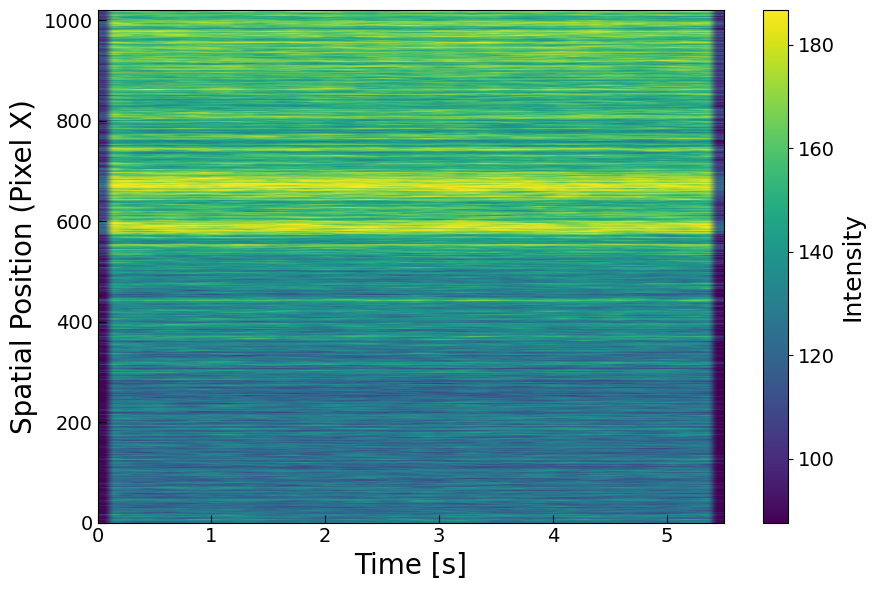

In [29]:
# --- 実行セクション ---

# 1. 画像フォルダまたはTIFFファイルのパスを指定
# Windowsのパス例: r"C:/Users/name/Desktop/data"
# input_path = "C:/Users/shiori/Downloads/20260107/20260107/2026_0109_203448854off866ecdloff"
input_path = "C:/Users/shiori/Downloads/20260107/20260107/2026_0109_203343854on"

# 2. 解析の実行
try:
    # compute_kymographでデータを読み込み
    # fps=Noneなら自動推測しますが、わかっていれば fps=10.0 のように指定してください
    res = compute_kymograph(input_path, fps=10, smooth_time=3)
    
    print(f"解析完了: {res.n_frames} frames, {res.x_len} spatial pixels")
    print(f"合計時間: {res.time_s[-1]:.2f} s")

    # 3. カイモグラフ（全体像）を表示
    # これを見て、どの位置(横線の位置)を解析したいか決めてください
    plot_kymograph(res)

except Exception as e:
    print(f"エラーが発生しました: {e}")

既存のデータを使用します
--- GMMによる自動判定 (範囲: ±10 pixel) ---

Processing: Pixel 650-670 (Center: 660)


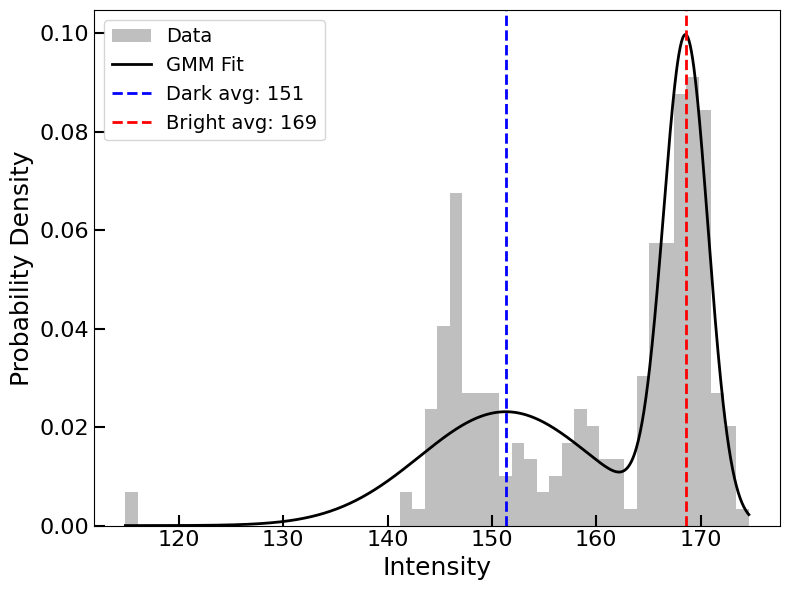

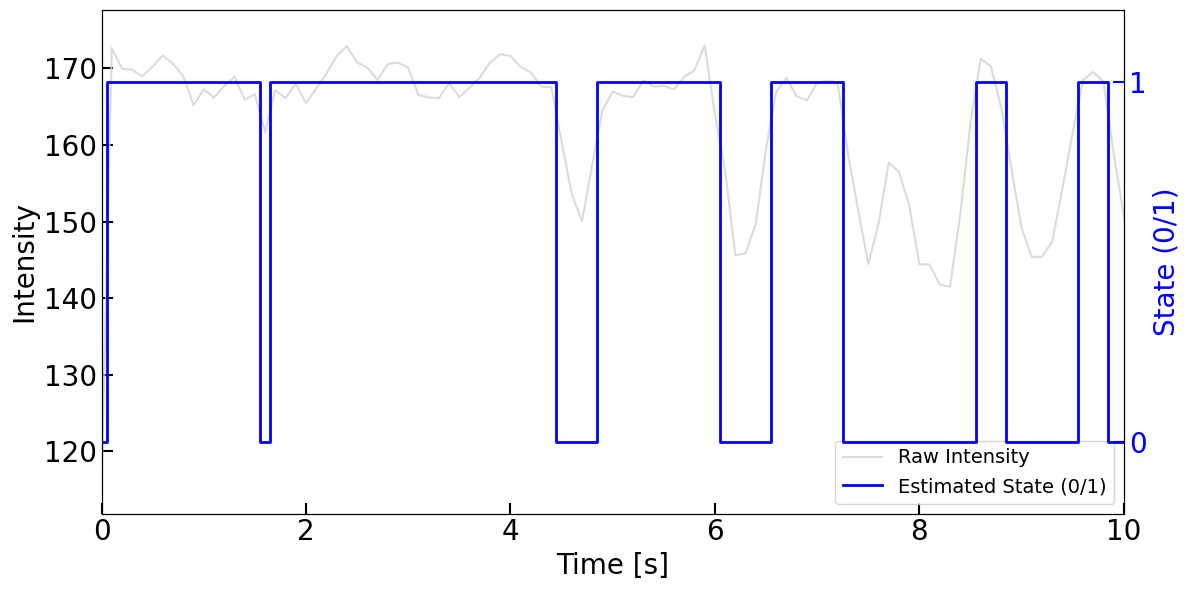


Processing: Pixel 580-600 (Center: 590)


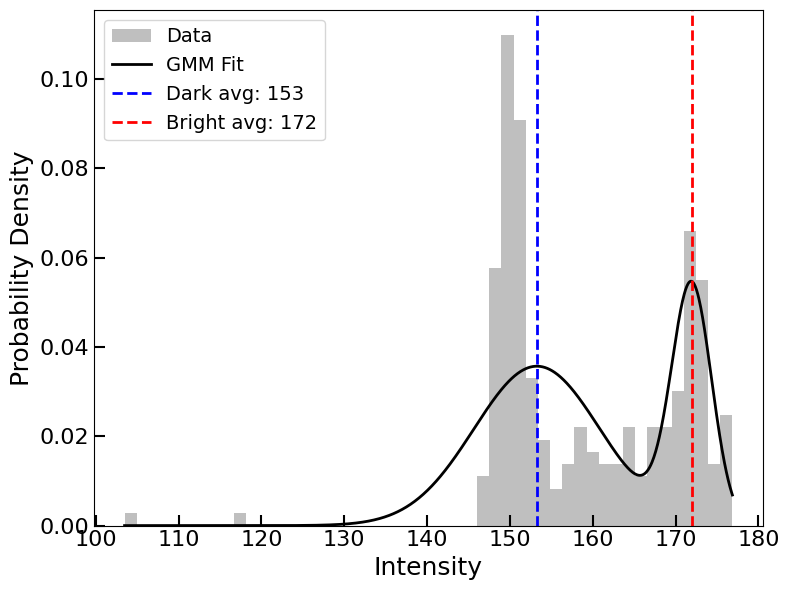

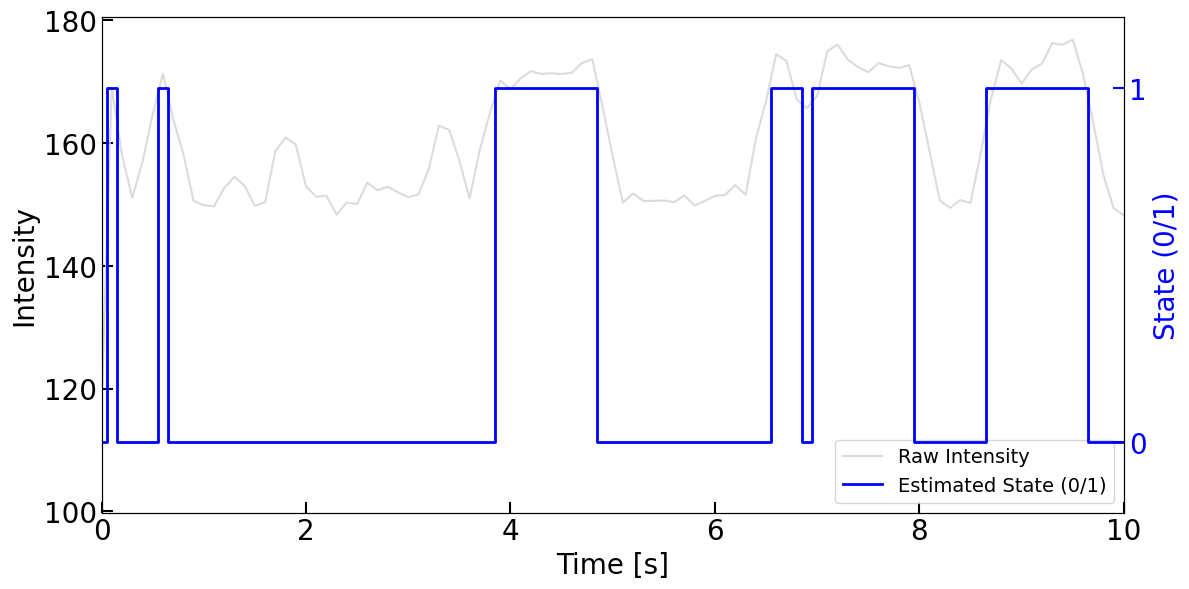

In [22]:
# --- 必要なライブラリのインポート ---
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

# --- GMM解析関数の定義 ---
def analyze_quantum_jumps(time_s, intensity_trace, idx_name, n_components=2):
    """
    GMMを用いて明暗(0/1)を自動判定し、ヒストグラムと判定結果を別々の図で表示する
    """
    # データを解析用に整形
    X = intensity_trace.reshape(-1, 1)
    
    # GMMでクラスタリング
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
    gmm.fit(X)
    
    # 0/1判定
    states = gmm.predict(X)
    
    # 明るい方を「1」にする処理
    means = gmm.means_.flatten()
    if means[0] > means[1]:
        states = 1 - states
        means = means[::-1] # [暗, 明]

    # --- 図1: ヒストグラムの描画 ---
    fig_hist = plt.figure(figsize=(8, 6)) # 新しいキャンバス1
    ax_hist = plt.gca()
    
    # ヒストグラム
    ax_hist.hist(intensity_trace, bins=50, density=True, alpha=0.5, color='gray', label='Data')
    
    # ガウス分布の推定線
    x_axis = np.linspace(intensity_trace.min(), intensity_trace.max(), 1000).reshape(-1, 1)
    logprob = gmm.score_samples(x_axis)
    ax_hist.plot(x_axis, np.exp(logprob), '-k', linewidth=2, label='GMM Fit')
    
    # 平均値の線
    ax_hist.axvline(means[0], color='blue', linestyle='--', linewidth=2, label=f'Dark avg: {means[0]:.0f}')
    ax_hist.axvline(means[1], color='red', linestyle='--', linewidth=2, label=f'Bright avg: {means[1]:.0f}')
    
    # ★文字サイズ設定 (ヒストグラム)
    # ax_hist.set_title(f'Histogram (Pixel: {idx_name})', fontsize=20)
    ax_hist.set_xlabel('Intensity', fontsize=18)
    ax_hist.set_ylabel('Probability Density', fontsize=18)
    ax_hist.tick_params(axis='both', labelsize=16, direction='in', length=8, width=1.5)
    ax_hist.legend(fontsize=14)
    
    plt.tight_layout()
    plt.show() # 図1を表示して区切る

    # --- 図2: 時系列トレースの描画 ---
    fig_trace = plt.figure(figsize=(12, 6)) # 新しいキャンバス2
    ax_trace = plt.gca()
    
    # 生データ (左軸)
    ax_trace.plot(time_s, intensity_trace, color='lightgray', alpha=0.8, label='Raw Intensity')
    ax_trace.set_ylabel('Intensity', fontsize=20)
    ax_trace.tick_params(axis='y', labelsize=20, direction='in', length=8, width=1.5)
    
    # 判定結果 (右軸)
    ax2 = ax_trace.twinx()
    ax2.step(time_s, states, where='mid', color='blue', linewidth=2.0, label='Estimated State (0/1)')
    ax2.set_ylabel('State (0/1)', color='blue', fontsize=20)
    ax2.set_yticks([0, 1])
    ax2.set_ylim(-0.2, 1.2)
    ax2.set_xlim(time_s[0], time_s[100])
    ax2.tick_params(axis='y', labelsize=20, colors='blue', direction='in', length=8, width=1.5)
    
    # 共通設定
    # ax_trace.set_title(f'Time Trace (Pixel: {idx_name})', fontsize=20)
    ax_trace.set_xlabel('Time [s]', fontsize=20)
    ax_trace.tick_params(axis='x', labelsize=20, direction='in', length=8, width=1.5)
    
    # 凡例の結合
    h1, l1 = ax_trace.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax_trace.legend(h1+h2, l1+l2, loc='lower right', fontsize=14)
    
    plt.tight_layout()
    plt.show() # 図2を表示
    
    return states


# --- 設定 ---
# ※ Windowsのパス設定のままにしています
input_path = "C:/Users/shiori/Downloads/20260107/20260107/2026_0109_203448854off866ecdloff"
target_indices = [660, 590]   # 中心となるピクセル位置
pixel_radius = 10             # 前後何ピクセルを見るか

# --- 実行 ---
try:
    # 1. データ読み込み (すでにresがあればスキップ)
    if 'res' not in locals(): 
        # compute_kymograph 関数が定義されている前提です
        res = compute_kymograph(input_path, fps=10, smooth_time=3)
        print(f"データ読み込み完了: {res.n_frames} frames")
    else:
        print("既存のデータを使用します")

    print(f"--- GMMによる自動判定 (範囲: ±{pixel_radius} pixel) ---")

    for idx in target_indices:
        # 範囲チェック
        start_col = max(0, idx - pixel_radius)
        end_col = min(res.profiles.shape[1], idx + pixel_radius + 1)
        
        # 範囲内の平均を取得
        intensity_trace = np.mean(res.profiles[:, start_col:end_col], axis=1)
        
        range_name = f"Pixel {start_col}-{end_col-1} (Center: {idx})"
        print(f"\nProcessing: {range_name}")

        # 解析実行
        analyze_quantum_jumps(res.time_s, intensity_trace, idx_name=range_name)

except Exception as e:
    print(f"エラーが発生しました: {e}")

既存のデータを使用します
--- GMMによる自動判定 (範囲: ±10 pixel) ---

Processing: Pixel 650-670 (Center: 660)


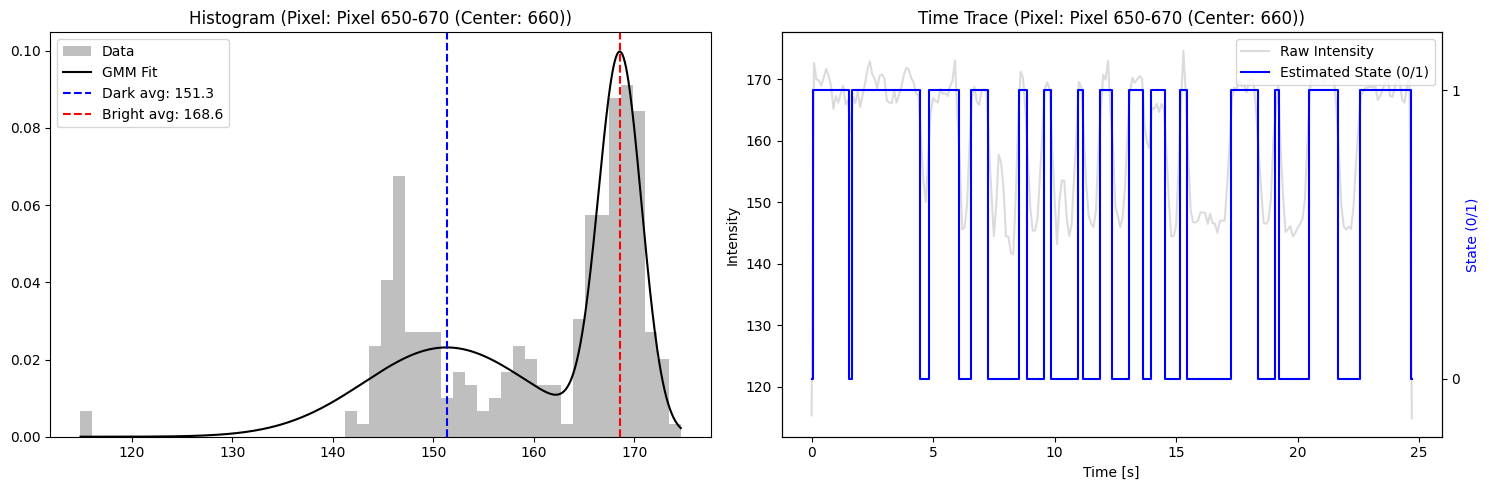


Processing: Pixel 580-600 (Center: 590)


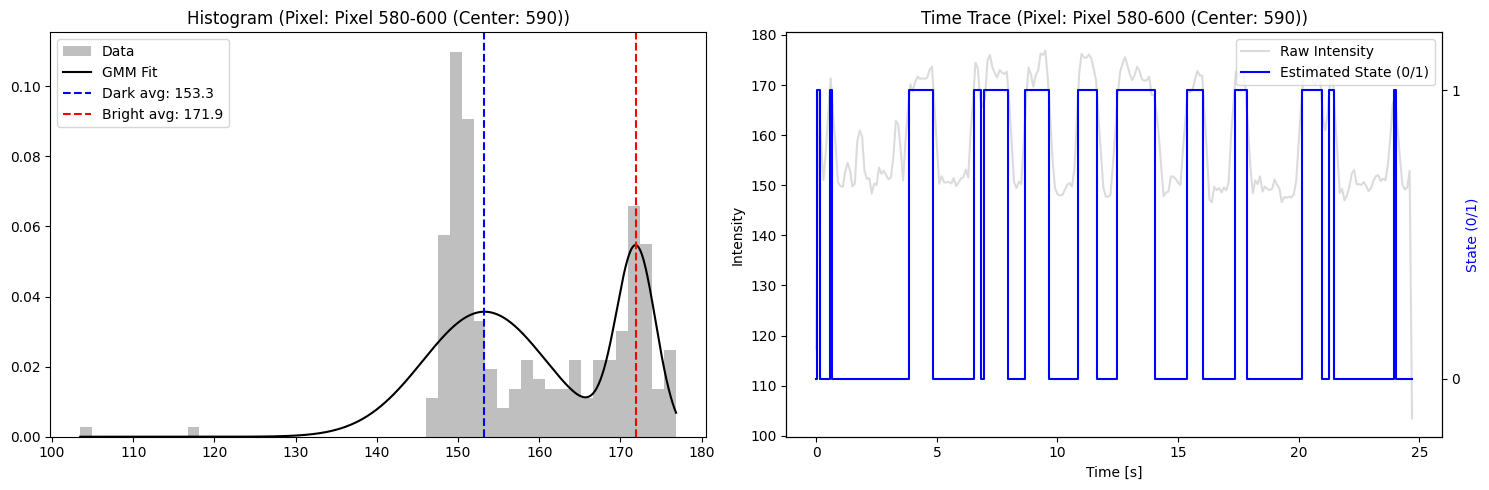

In [8]:
# --- 必要なライブラリのインポート ---
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

# --- GMM解析関数の定義（これを実行しておく必要があります） ---
def analyze_quantum_jumps(time_s, intensity_trace, idx_name, n_components=2):
    """
    GMMを用いて明暗(0/1)を自動判定し、ヒストグラムと判定結果を表示する
    """
    # データを解析用に整形
    X = intensity_trace.reshape(-1, 1)
    
    # GMMでクラスタリング（2つの山に分ける）
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
    gmm.fit(X)
    
    # 0/1判定
    states = gmm.predict(X)
    
    # 明るい方を「1」にする処理
    means = gmm.means_.flatten()
    if means[0] > means[1]:
        states = 1 - states
        means = means[::-1] # [暗, 明]

    # --- プロット ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 1. ヒストグラム
    ax_hist = axes[0]
    ax_hist.hist(intensity_trace, bins=50, density=True, alpha=0.5, color='gray', label='Data')
    # ガウス分布の推定線（参考）
    x_axis = np.linspace(intensity_trace.min(), intensity_trace.max(), 1000).reshape(-1, 1)
    logprob = gmm.score_samples(x_axis)
    ax_hist.plot(x_axis, np.exp(logprob), '-k', label='GMM Fit')
    # 推定された平均値に線を引く
    ax_hist.axvline(means[0], color='blue', linestyle='--', label=f'Dark avg: {means[0]:.1f}')
    ax_hist.axvline(means[1], color='red', linestyle='--', label=f'Bright avg: {means[1]:.1f}')
    ax_hist.set_title(f'Histogram (Pixel: {idx_name})')
    ax_hist.legend()

    # 2. 時系列トレース
    ax_trace = axes[1]
    ax_trace.plot(time_s, intensity_trace, color='lightgray', alpha=0.8, label='Raw Intensity')
    
    # 判定結果(0/1)を右軸に
    ax2 = ax_trace.twinx()
    ax2.step(time_s, states, where='mid', color='blue', linewidth=1.5, label='Estimated State (0/1)')
    ax2.set_ylabel('State (0/1)', color='blue')
    ax2.set_yticks([0, 1])
    ax2.set_ylim(-0.2, 1.2)
    
    ax_trace.set_title(f'Time Trace (Pixel: {idx_name})')
    ax_trace.set_xlabel('Time [s]')
    ax_trace.set_ylabel('Intensity')
    
    # 凡例
    h1, l1 = ax_trace.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax_trace.legend(h1+h2, l1+l2, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return states


# --- 設定 ---
input_path = "C:/Users/shiori/Downloads/20260107/20260107/2026_0109_203448854off866ecdloff"
target_indices = [660, 590]   # 中心となるピクセル位置
pixel_radius = 10             # 前後何ピクセルを見るか（例: 10なら ±10ピクセルの平均）

# --- 実行 ---
try:
    # 1. データ読み込み (まだ読み込んでなければ)
    if 'res' not in locals(): 
        res = compute_kymograph(input_path, fps=10, smooth_time=3)
        print(f"データ読み込み完了: {res.n_frames} frames")
    else:
        print("既存のデータを使用します")

    print(f"--- GMMによる自動判定 (範囲: ±{pixel_radius} pixel) ---")

    for idx in target_indices:
        # 範囲を決定（画像の端っこを超えないように max/min でガード）
        start_col = max(0, idx - pixel_radius)
        end_col = min(res.profiles.shape[1], idx + pixel_radius + 1)
        
        # ★ここが変更点: 指定範囲を切り出して、空間方向(axis=1)に平均をとる
        # これでノイズが低減されたきれいな波形になります
        intensity_trace = np.mean(res.profiles[:, start_col:end_col], axis=1)
        
        # 表示用の名前（例: "Pixel 650-670"）
        range_name = f"Pixel {start_col}-{end_col-1} (Center: {idx})"
        print(f"\nProcessing: {range_name}")

        # GMM解析関数に投げる
        analyze_quantum_jumps(res.time_s, intensity_trace, idx_name=range_name)

except Exception as e:
    print(f"エラーが発生しました: {e}")


Processing: Pixel 650-670 (Center: 660)


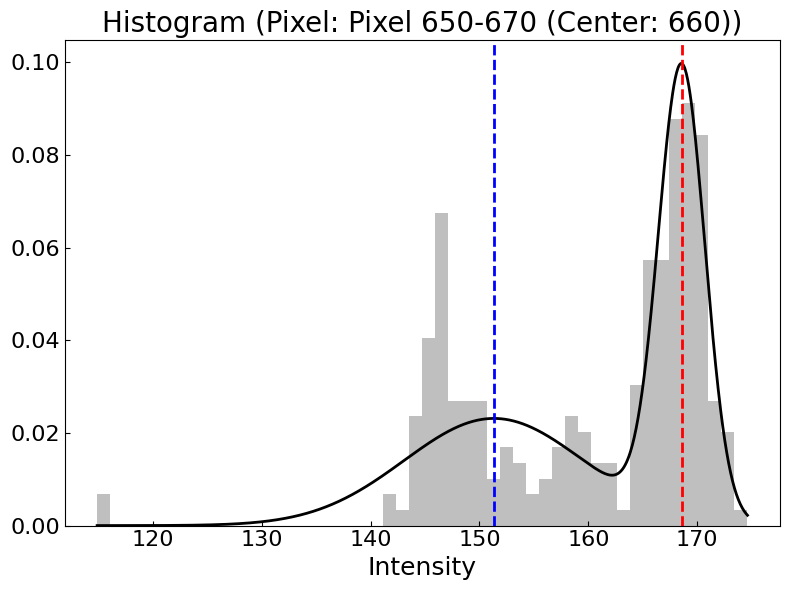

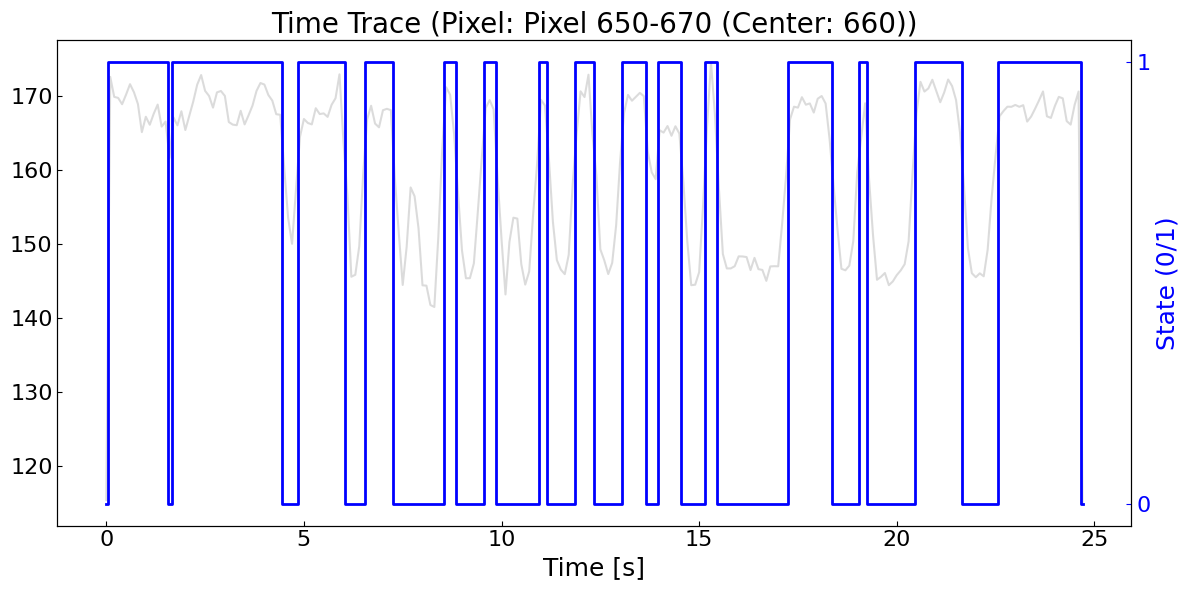


=== 解析結果 (Pixel: Pixel 650-670 (Center: 660)) ===
検出されたOffイベント数: 14 回
平均Off時間: 0.7857 s
最大Off時間: 1.8000 s

Processing: Pixel 580-600 (Center: 590)


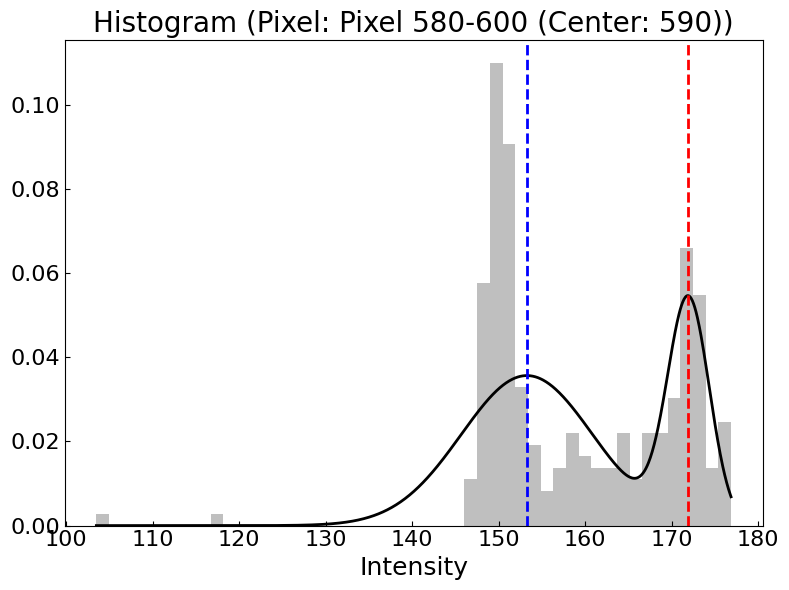

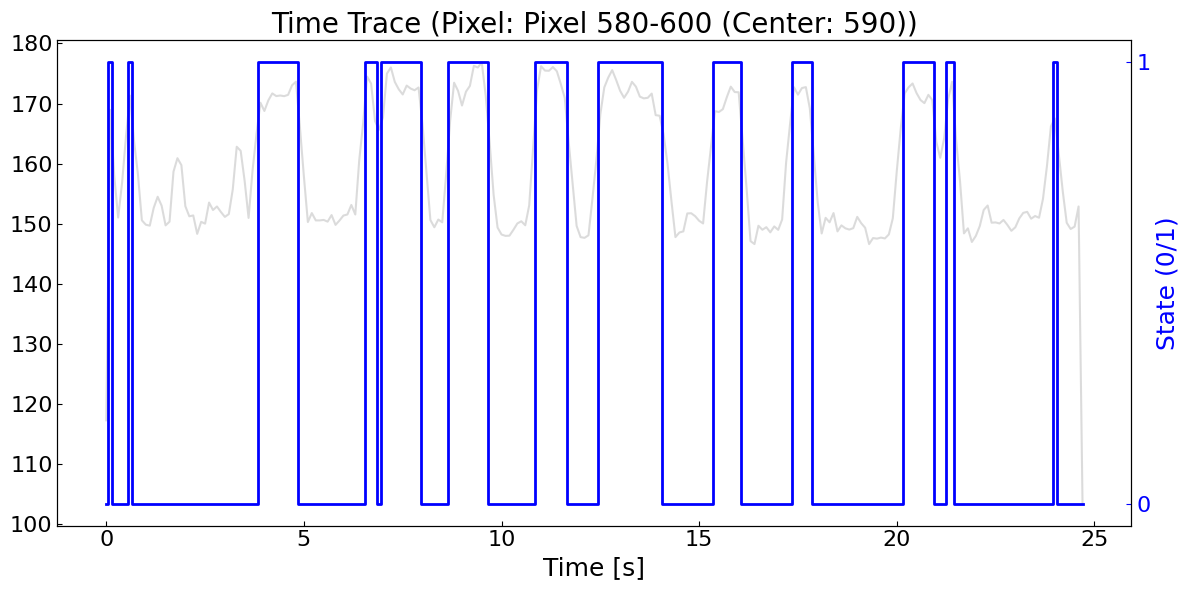


=== 解析結果 (Pixel: Pixel 580-600 (Center: 590)) ===
検出されたOffイベント数: 12 回
平均Off時間: 1.3167 s
最大Off時間: 3.2000 s

--------------------------------------------------
▼ 取得したOff時間のリスト (最初の10個を表示)
Pixel 660: [np.float64(0.1), np.float64(0.4), np.float64(0.5), np.float64(1.3), np.float64(0.7000000000000001), np.float64(1.1), np.float64(0.7000000000000001), np.float64(0.7000000000000001), np.float64(0.30000000000000004), np.float64(0.6000000000000001)] ... (全14個)
Pixel 590: [np.float64(0.4), np.float64(3.2), np.float64(1.7000000000000002), np.float64(0.1), np.float64(0.7000000000000001), np.float64(1.2000000000000002), np.float64(0.8), np.float64(1.3), np.float64(1.3), np.float64(2.3000000000000003)] ... (全12個)


In [26]:
# --- 必要なライブラリ ---
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np
from itertools import groupby

# --- GMM解析関数の定義 ---
def analyze_quantum_jumps(time_s, intensity_trace, idx_name, n_components=2):
    """
    GMMを用いて0/1判定を行い、グラフ表示に加え「0の連続時間リスト」を返す
    """
    # データを解析用に整形
    X = intensity_trace.reshape(-1, 1)
    
    # GMMでクラスタリング
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
    gmm.fit(X)
    states = gmm.predict(X)
    
    # 明るい方を「1」にする処理
    means = gmm.means_.flatten()
    if means[0] > means[1]:
        states = 1 - states
        means = means[::-1] # [暗, 明]

    # --- プロット (ヒストグラム) ---
    fig_hist = plt.figure(figsize=(8, 6))
    ax_hist = plt.gca()
    ax_hist.hist(intensity_trace, bins=50, density=True, alpha=0.5, color='gray', label='Data')
    x_axis = np.linspace(intensity_trace.min(), intensity_trace.max(), 1000).reshape(-1, 1)
    logprob = gmm.score_samples(x_axis)
    ax_hist.plot(x_axis, np.exp(logprob), '-k', linewidth=2, label='GMM Fit')
    ax_hist.axvline(means[0], color='blue', linestyle='--', linewidth=2, label=f'Dark avg: {means[0]:.0f}')
    ax_hist.axvline(means[1], color='red', linestyle='--', linewidth=2, label=f'Bright avg: {means[1]:.0f}')
    ax_hist.set_title(f'Histogram (Pixel: {idx_name})', fontsize=20)
    ax_hist.set_xlabel('Intensity', fontsize=18)
    ax_hist.tick_params(labelsize=16, direction='in')
    plt.tight_layout()
    plt.show()

    # --- プロット (時系列) ---
    fig_trace = plt.figure(figsize=(12, 6))
    ax_trace = plt.gca()
    ax_trace.plot(time_s, intensity_trace, color='lightgray', alpha=0.8, label='Raw')
    ax2 = ax_trace.twinx()
    ax2.step(time_s, states, where='mid', color='blue', linewidth=2.0, label='State (0/1)')
    ax2.set_ylabel('State (0/1)', color='blue', fontsize=18)
    ax2.set_yticks([0, 1])
    ax_trace.set_title(f'Time Trace (Pixel: {idx_name})', fontsize=20)
    ax_trace.set_xlabel('Time [s]', fontsize=18)
    ax_trace.tick_params(labelsize=16, direction='in')
    ax2.tick_params(labelsize=16, direction='in', colors='blue')
    plt.tight_layout()
    plt.show()
    
    # --- ★追加機能: 0の連続時間を計算 ---
    dt = time_s[1] - time_s[0] # 1フレームの時間
    off_durations = [] # ここに時間を格納します

    # groupbyで同じ値が続いているグループを作る
    for key, group in groupby(states):
        if key == 0: # 0 (Dark) の場合だけ
            length = len(list(group)) # 連続しているフレーム数
            duration = length * dt    # 時間に変換
            off_durations.append(duration)

    off_durations = off_durations[1:-1]

    # 結果の表示
    if off_durations:
        print(f"\n=== 解析結果 (Pixel: {idx_name}) ===")
        print(f"検出されたOffイベント数: {len(off_durations)} 回")
        print(f"平均Off時間: {np.mean(off_durations):.4f} s")
        print(f"最大Off時間: {np.max(off_durations):.4f} s")
        # print(f"Off時間のリスト: {off_durations}") # 長くなるのでコメントアウトしてます
    else:
        print("\nOff状態(0)は検出されませんでした。")

    return states, off_durations


# --- 設定 ---
input_path = "C:/Users/shiori/Downloads/20260107/20260107/2026_0109_203448854off866ecdloff"
target_indices = [660, 590]
pixel_radius = 10

# --- 実行 ---
try:
    if 'res' not in locals(): 
        res = compute_kymograph(input_path, fps=10, smooth_time=3)
    
    all_off_times = {} # あとでデータをまとめる用

    for idx in target_indices:
        start_col = max(0, idx - pixel_radius)
        end_col = min(res.profiles.shape[1], idx + pixel_radius + 1)
        intensity_trace = np.mean(res.profiles[:, start_col:end_col], axis=1)
        range_name = f"Pixel {start_col}-{end_col-1} (Center: {idx})"
        
        print(f"\nProcessing: {range_name}")
        
        # 関数呼び出し (戻り値としてリストを受け取る)
        states, off_times = analyze_quantum_jumps(res.time_s, intensity_trace, idx_name=range_name)
        
        # 辞書に保存 (例: all_off_times[660] で後からリストを取り出せます)
        all_off_times[idx] = off_times

    # --- 最後にリストの中身を確認したい場合 ---
    print("\n--------------------------------------------------")
    print("▼ 取得したOff時間のリスト (最初の10個を表示)")
    for idx in target_indices:
        times = all_off_times[idx]
        print(f"Pixel {idx}: {times[:10]} ... (全{len(times)}個)")

except Exception as e:
    print(f"エラーが発生しました: {e}")